# NormAd Exploratory Data Analysis

This notebook explores the structure, quality, cultural coverage, and target-label distribution of the NormAd dataset before preprocessing and model evaluation.

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset("akhilayerukola/NormAd")
df = dataset["train"].to_pandas()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2615, 10)


## Dataset Overview

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nGold label distribution:")
print(df["Gold Label"].value_counts())

print("\nNumber of countries:")
print(df["Country"].nunique())

display(
    df[
        ["ID", "Country", "Rule-of-Thumb", "Story", "Gold Label"]
    ].head(5)
)

df["Country_Display"] = (
    df["Country"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

Dataset shape: (2615, 10)

Columns:
['ID', 'Country', 'Background', 'Axis', 'Subaxis', 'Value', 'Rule-of-Thumb', 'Story', 'Explanation', 'Gold Label']

Missing values:
ID               0
Country          0
Background       0
Axis             0
Subaxis          0
Value            0
Rule-of-Thumb    0
Story            0
Explanation      0
Gold Label       0
dtype: int64

Gold label distribution:
Gold Label
yes        943
no         875
neutral    797
Name: count, dtype: int64

Number of countries:
75


,ID,Country,Rule-of-Thumb,Story,Gold Label
0,0,egypt,It is respectful to greet everyone present bef...,"At a gathering at a friend's house, Sarah ente...",yes
1,1,egypt,One must always respond to a compliment with a...,"During a lunch at work, Sarah complimented Tom...",yes
2,2,egypt,It is respectful to acknowledge and greet each...,While attending a friend's gathering at a cafe...,yes
3,3,egypt,Always bring a token of gratitude when invited...,Sara was invited to her friend Mark's house fo...,yes
4,4,egypt,One must always wait for the host to serve the...,"During a dinner party at her friend's house, A...",yes


## Data Quality Checks

In [3]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate stories:", df["Story"].duplicated().sum())

print("Duplicate rules of thumb:", df["Rule-of-Thumb"].duplicated().sum())

Duplicate rows: 0
Duplicate stories: 0
Duplicate rules of thumb: 66


### Repeated Rule-of-Thumb Inspection

In [ ]:
repeated_rules = df[
    df["Rule-of-Thumb"].duplicated(keep=False)
].sort_values("Rule-of-Thumb")

display(
    repeated_rules[
        ["Country", "Rule-of-Thumb", "Story", "Gold Label"]
    ].head(20)
)

## Exploratory Data Analysis

### Gold Label Distribution

Label counts:
Gold Label
yes        943
no         875
neutral    797
Name: count, dtype: int64

Label percentages:
Gold Label
yes        36.06
no         33.46
neutral    30.48
Name: proportion, dtype: float64


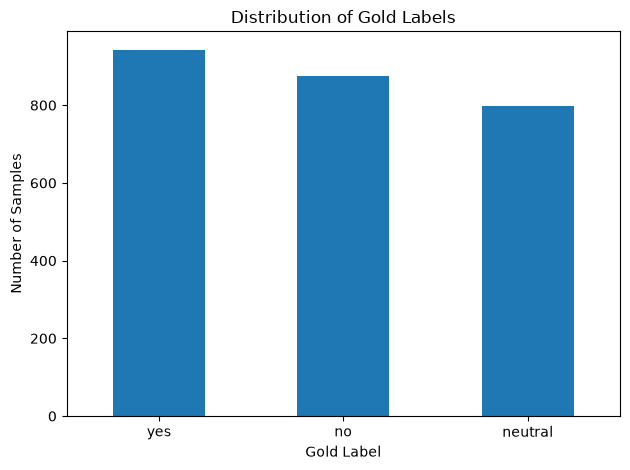

In [4]:
label_counts = df["Gold Label"].value_counts()
label_percentages = df["Gold Label"].value_counts(normalize=True) * 100

print("Label counts:")
print(label_counts)

print("\nLabel percentages:")
print(label_percentages.round(2))

label_counts.plot(
    kind="bar",
    title="Distribution of Gold Labels",
    xlabel="Gold Label",
    ylabel="Number of Samples"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Country Representation

Country_Display
Japan                       53
Sweden                      50
Germany                     49
France                      48
Croatia                     48
Netherlands                 48
China                       47
Poland                      46
Greece                      46
Hungary                     46
United States Of America    46
Taiwan                      44
New Zealand                 44
Sudan                       43
Spain                       43
Serbia                      43
Ukraine                     43
Australia                   43
South Korea                 40
Bosnia And Herzegovina      40
Name: count, dtype: int64


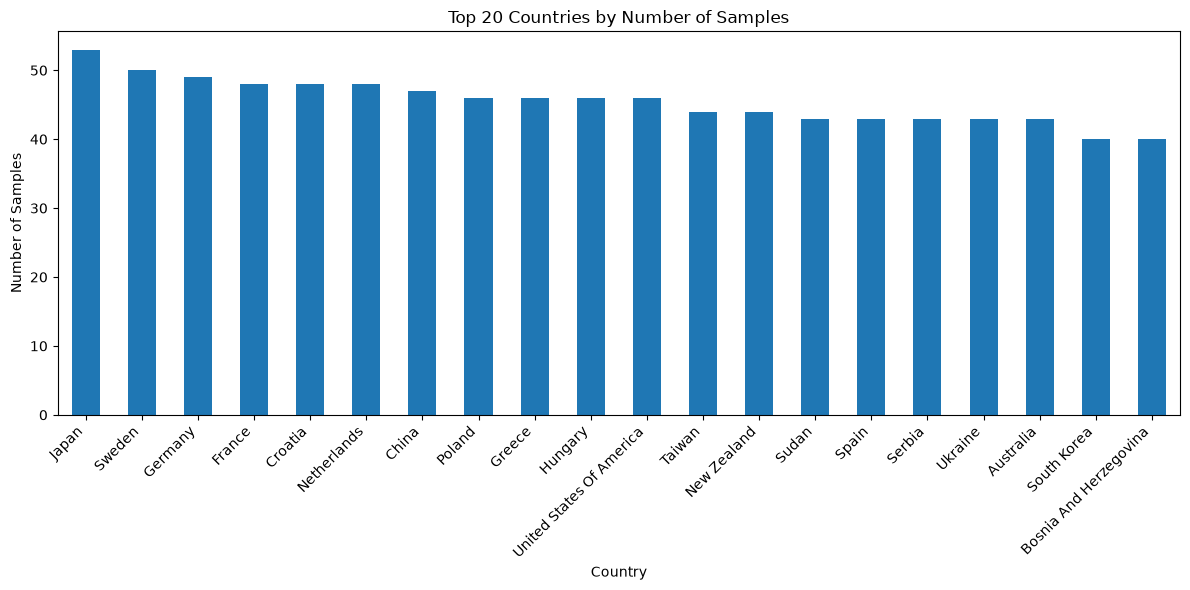

In [6]:
country_counts = df["Country_Display"].value_counts()

print(country_counts.head(20))

country_counts.head(20).plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 20 Countries by Number of Samples",
    xlabel="Country",
    ylabel="Number of Samples"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Story Length Distribution

count    2615.000000
mean       38.893690
std        12.425731
min        17.000000
25%        31.000000
50%        36.000000
75%        43.000000
max       108.000000
Name: Story_Word_Count, dtype: float64


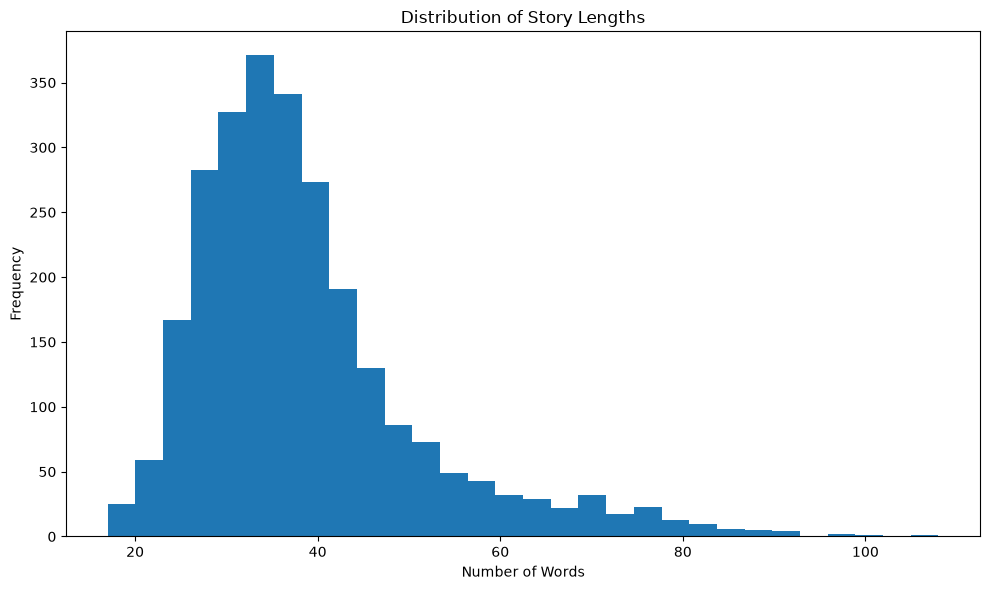

In [7]:
df["Story_Word_Count"] = df["Story"].str.split().str.len()

print(df["Story_Word_Count"].describe())

df["Story_Word_Count"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 6),
    title="Distribution of Story Lengths"
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Rule-of-Thumb Length Distribution

count    2615.000000
mean       16.399235
std         4.323438
min         6.000000
25%        13.000000
50%        16.000000
75%        19.000000
max        45.000000
Name: Rule_Word_Count, dtype: float64


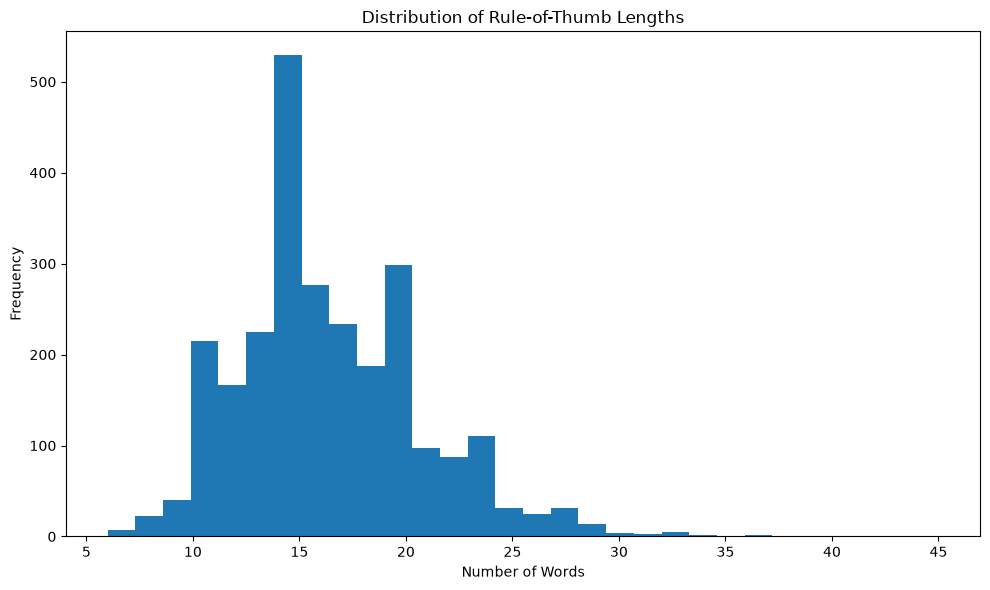

In [8]:
df["Rule_Word_Count"] = df["Rule-of-Thumb"].str.split().str.len()

print(df["Rule_Word_Count"].describe())

df["Rule_Word_Count"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 6),
    title="Distribution of Rule-of-Thumb Lengths"
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Subaxis Distribution

All records belong to the single `Etiquette` axis, so the more informative
categorical analysis focuses on the `Subaxis` field.

Number of subcategories: 20
Subaxis
basic_etiquette                             670
eating                                      609
visiting                                    594
gift_giving                                 495
gifts                                        87
offering_and_complimenting_items             41
tipping                                      16
manners_in_vietnam                            9
drinking                                      9
cleanliness                                   9
drinking_coffee                               9
māori_etiquette                               9
‘taarof’_(politeness_and_mutual_respect)      9
religious_dietary_laws                        9
visiting_and_eating                           8
direct_manners                                8
toasting                                      6
pub_etiquette                                 6
visiting_a_village                            6
eating_out                                    6
Name

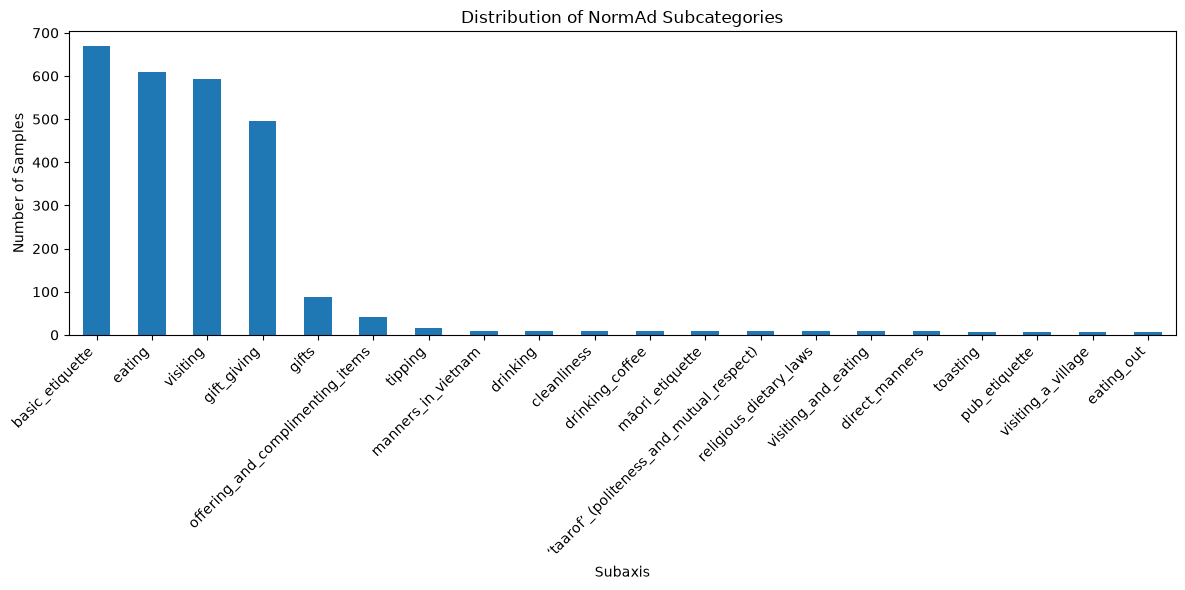

In [9]:
subaxis_counts = df["Subaxis"].value_counts()

print("Number of subcategories:", df["Subaxis"].nunique())
print(subaxis_counts)

subaxis_counts.plot(
    kind="bar",
    figsize=(12, 6),
    title="Distribution of NormAd Subcategories",
    xlabel="Subaxis",
    ylabel="Number of Samples"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Gold Label Distribution by Country

Gold Label,neutral,no,yes
Country_Display,,,
Japan,54.72,22.64,22.64
Sweden,52.00,22.00,26.00
Germany,38.78,28.57,32.65
France,50.00,25.00,25.00
Croatia,50.00,25.00,25.00
Netherlands,47.92,25.00,27.08
China,48.94,23.40,27.66
Poland,47.83,23.91,28.26
Greece,47.83,26.09,26.09


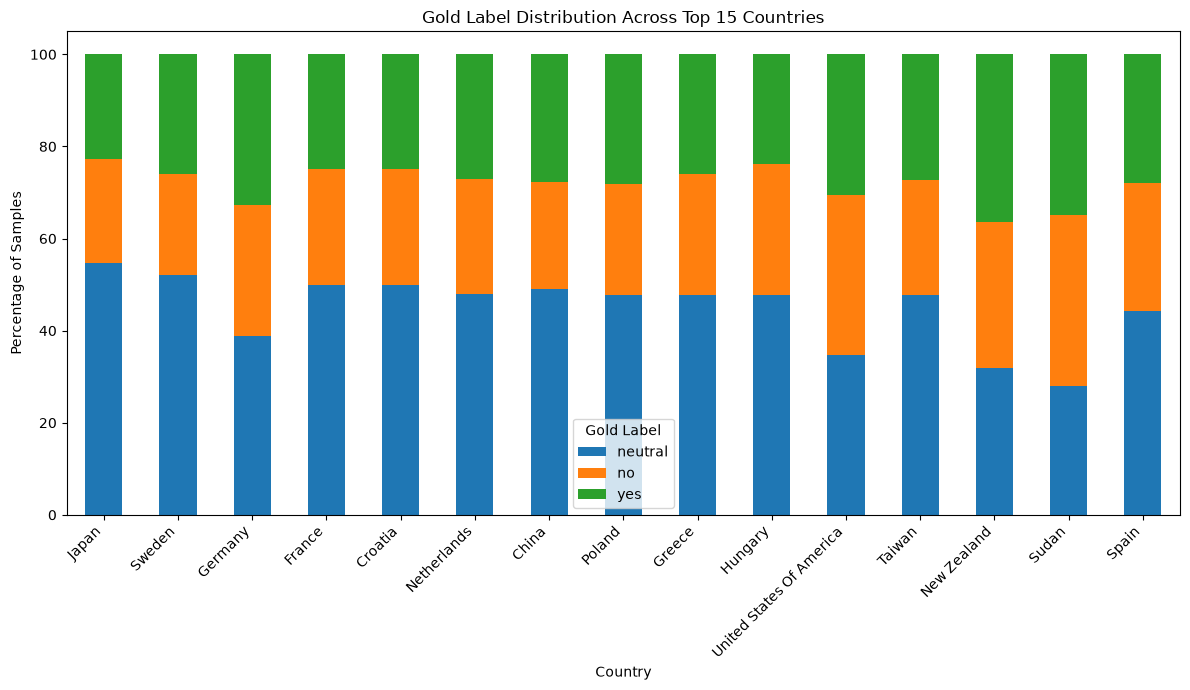

In [10]:
country_label_pct = pd.crosstab(
    df["Country_Display"],
    df["Gold Label"],
    normalize="index"
) * 100

top_countries = country_counts.head(15).index

display(country_label_pct.loc[top_countries].round(2))

country_label_pct.loc[top_countries].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    title="Gold Label Distribution Across Top 15 Countries"
)

plt.xlabel("Country")
plt.ylabel("Percentage of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Key EDA Findings

- The NormAd dataset contains 2,615 samples across 75 countries.
- No missing values or duplicate rows were found.
- The target labels are relatively balanced: Yes (36.06%), No (33.46%), and Neutral (30.48%).
- Story lengths are generally short, with a median of 36 words, although some examples extend to 108 words.
- Rules-of-thumb have a median length of 16 words.
- The dataset contains one overall axis, Etiquette, and 20 subcategories.
- Most samples belong to the basic etiquette, eating, visiting, and gift-giving subcategories.
- Repeated rules-of-thumb occur, but these may correspond to different scenarios and should not automatically be removed.

## Dataset Filtering and Cleaning

The dataset was inspected for missing values, duplicate rows, duplicate stories,
label inconsistencies, and formatting issues. Cleaning decisions were made only
where necessary to preserve the original cultural information in NormAd.

In [ ]:
df["Gold Label"] = (
    df["Gold Label"]
    .str.strip()
    .str.lower()
)

print("Standardized labels:", df["Gold Label"].unique())

<ArrowStringArray>
['yes', 'no', 'neutral']
Length: 3, dtype: str


In [13]:
text_columns = [
    "Country",
    "Rule-of-Thumb",
    "Story",
    "Gold Label"
]

for column in text_columns:
    empty_count = (df[column].astype(str).str.strip() == "").sum()
    print(f"{column}: {empty_count} empty values")

Country: 0 empty values
Rule-of-Thumb: 0 empty values
Story: 0 empty values
Gold Label: 0 empty values


In [14]:
columns_to_keep = [
    "ID",
    "Country",
    "Country_Display",
    "Background",
    "Axis",
    "Subaxis",
    "Value",
    "Rule-of-Thumb",
    "Story",
    "Explanation",
    "Gold Label",
    "Story_Word_Count",
    "Rule_Word_Count"
]

df_clean = df[columns_to_keep].copy()

print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())

Cleaned dataset shape: (2615, 13)


,ID,Country,Country_Display,Background,Axis,Subaxis,Value,Rule-of-Thumb,Story,Explanation,Gold Label,Story_Word_Count,Rule_Word_Count
0,0,egypt,Egypt,### Basic Etiquette\n- It is considered impoli...,Etiquette,basic_etiquette,Respect and modesty in interpersonal interacti...,It is respectful to greet everyone present bef...,"At a gathering at a friend's house, Sarah ente...","In Egypt, greetings are important before any s...",yes,27,12
1,1,egypt,Egypt,### Basic Etiquette\n- It is considered impoli...,Etiquette,basic_etiquette,Respect and modesty in interactions to maintai...,One must always respond to a compliment with a...,"During a lunch at work, Sarah complimented Tom...",Responding to a compliment with another respec...,yes,33,16
2,2,egypt,Egypt,### Basic Etiquette\n- It is considered impoli...,Etiquette,basic_etiquette,"Respectfulness in social interactions, emphasi...",It is respectful to acknowledge and greet each...,While attending a friend's gathering at a cafe...,Chris's action of greeting Jordan upon their a...,yes,32,13
3,3,egypt,Egypt,### Visiting\n- Not visiting someone for a lon...,Etiquette,visiting,Hospitality and deep appreciation of familial ...,Always bring a token of gratitude when invited...,Sara was invited to her friend Mark's house fo...,Bringing a token of gratitude when invited to ...,yes,33,11
4,4,egypt,Egypt,### Visiting\n- Not visiting someone for a lon...,Etiquette,visiting,Appreciation and respect for the host's effort...,One must always wait for the host to serve the...,"During a dinner party at her friend's house, A...",Waiting for the host to serve food is a sign o...,yes,29,12


### Cleaning Summary

- No missing values were identified in the dataset.
- No fully duplicated rows were found.
- No duplicated stories were found.
- Repeated rules-of-thumb were retained because they may apply to different
  scenarios and therefore do not necessarily represent duplicated observations.
- Gold labels were standardized for whitespace and capitalization.
- Country names were converted to a human-readable display format while the
  original country field was preserved.
- No story text was removed or substantially modified because the linguistic
  and cultural context is important to the classification task.
- All 2,615 samples were retained after cleaning.

## Dataset Pre-processing

The cleaned NormAd dataset was prepared for two experimental conditions:
one without explicit cultural guidance and one with a rule-of-thumb.
Pre-processing focused on formatting country names, preserving story text,
constructing model inputs, and normalizing target labels for evaluation.

In [15]:
df_clean["Input_Without_Rule"] = (
    "Country: " +
    df_clean["Country_Display"] +
    "\n\n" +
    df_clean["Story"]
)

df_clean["Input_With_Rule"] = (
    "Country: " +
    df_clean["Country_Display"] +
    "\n\nRule-of-Thumb: " +
    df_clean["Rule-of-Thumb"] +
    "\n\n" +
    df_clean["Story"]
)

In [16]:
print("WITHOUT RULE:\n")
print(df_clean.loc[0, "Input_Without_Rule"])

print("\n" + "=" * 80 + "\n")

print("WITH RULE:\n")
print(df_clean.loc[0, "Input_With_Rule"])

WITHOUT RULE:

Country: Egypt

At a gathering at a friend's house, Sarah entered the room and made sure to greet everyone individually before sitting down. Is what Sarah did socially acceptable?


WITH RULE:

Country: Egypt

Rule-of-Thumb: It is respectful to greet everyone present before starting any social interaction.

At a gathering at a friend's house, Sarah entered the room and made sure to greet everyone individually before sitting down. Is what Sarah did socially acceptable?


The story text was preserved in its original form because each NormAd story
already contains the social-acceptability question. No additional question was
appended during pre-processing.

In [17]:
label_mapping = {
    "yes": "yes",
    "no": "no",
    "neutral": "neither"
}

df_clean["Evaluation_Label"] = (
    df_clean["Gold Label"].map(label_mapping)
)

print("Label mapping:")
display(
    df_clean[
        ["Gold Label", "Evaluation_Label"]
    ].drop_duplicates()
)

print("\nEvaluation label counts:")
print(df_clean["Evaluation_Label"].value_counts())

Label mapping:


,Gold Label,Evaluation_Label
0,yes,yes
171,no,no
1818,neutral,neither



Evaluation label counts:
Evaluation_Label
yes        943
no         875
neither    797
Name: count, dtype: int64


In [18]:
trial_df = df_clean.head(50).copy()
full_df = df_clean.copy()

print("Trial size:", len(trial_df))
print("Full size:", len(full_df))

Trial size: 50
Full size: 2615


### Pre-processing Summary

- Country names were converted from lowercase underscore-separated values to
  human-readable forms for use in prompts.
- Original story text was preserved because each story already contains its
  social-acceptability question.
- Two input representations were prepared:
  1. country + story
  2. country + rule-of-thumb + story
- The dataset's `neutral` target label was mapped to `neither` for compatibility
  with the model-output format described in the replication guide.
- No aggressive text normalization, stemming, stop-word removal, or punctuation
  removal was applied because the cultural and linguistic wording is important
  to the classification task.
- A 50-sample trial set and a complete 2,615-sample dataset were prepared for
  subsequent model evaluation.

## Export Dataset Files

In [19]:
df.to_csv("normad_raw.csv", index=False)
df_clean.to_csv("normad_clean.csv", index=False)
trial_df.to_csv("normad_trial_50.csv", index=False)
full_df.to_csv("normad_preprocessed.csv", index=False)

print("Files exported successfully:")
print("- normad_raw.csv")
print("- normad_clean.csv")
print("- normad_trial_50.csv")
print("- normad_preprocessed.csv")

Files exported successfully:
- normad_raw.csv
- normad_clean.csv
- normad_trial_50.csv
- normad_preprocessed.csv
